In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Color detectado: Rosa


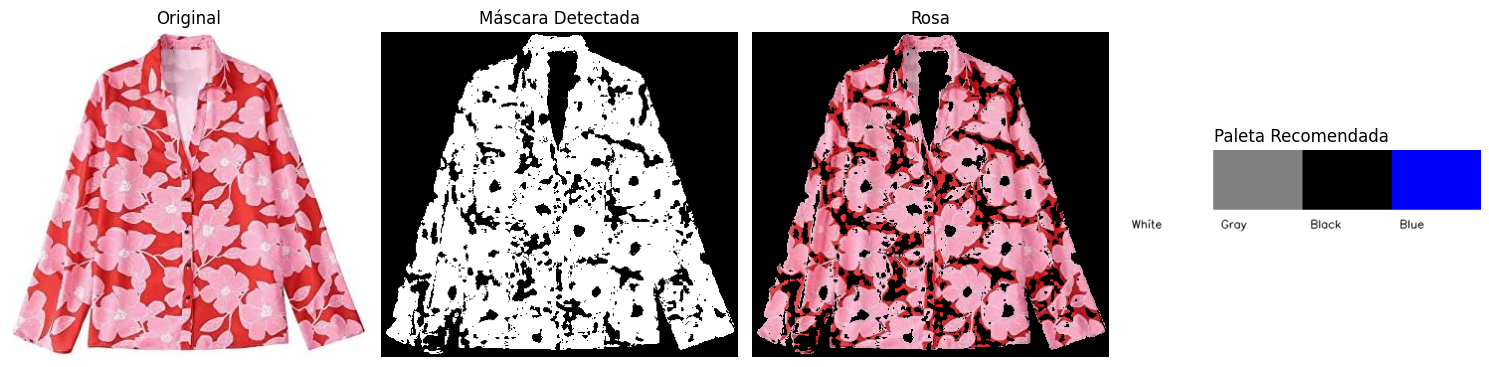

In [ ]:

def main():
    '''
    Función principal para ejecutar la detección de color en una imagen.
    '''

    #Ejemplos de varias prendas, descomentar para utilizar.

    #Blue_dress = 'Blue_Dress.jpg' 
    #color_detector(Blue_dress)
    
    #Red_dress = 'Red_dress.jpg'
    #color_detector(Red_dress)
    
    #Yellow_sweater = 'Yellow_sweater.jpg'
    #color_detector(Yellow_sweater)
    
    #Green_shirt = 'Green_tshirt.jpg'
    #color_detector(Green_shirt)
    
    #Black_skirt = 'Black_skirt.jpg'
    #color_detector(Black_skirt)
    
    #Gray_shirt = 'Gray_shirt.jpg'
    #color_detector(Gray_shirt)
    
    #Pink_blazer = 'Pink_blazer.jpg'
    #color_detector(Pink_blazer)
    
    #Orange_shirt = 'Orange_shirt.jpg'
    #color_detector(Orange_shirt)

    # Se define la ruta de la imagen a procesar
    Estampado = 'rosita.jpg'
    color_detector(Estampado)


def Color_counter(image, lower_color, upper_color):
    """
    Cuenta la cantidad de píxeles que caen dentro de un rango de color.

    Args:
        image: Imagen en espacio de color HSV.
        lower_color: Rango inferior del color.
        upper_color: Rango superior del color.

    Returns:
        int: Número de píxeles detectados de cada color.
    """

    mask = cv2.inRange(image, lower_color, upper_color)
    num_color = cv2.countNonZero(mask)
    
    return num_color


def draw_palette(recommended_colors, recommended_bgr):
    """
    Plotea la paleta de colores sugerida.
    """

    box_width = 120
    palette_height = 120
    palette_width = box_width * len(recommended_colors)

    # Crear un lienzo en blanco                                              #blanco = 255
    palette = np.ones((palette_height, palette_width, 3), dtype=np.uint8) * 255
    
    for i in range(len(recommended_colors)):
        # Calcula las coordenadas x inicial y final para posicionar los cuadros en serie
        x1 = i * box_width
        x2 = (i + 1) * box_width

        # Dibujar el rectángulo del color
        cv2.rectangle(palette, (x1, 0), (x2, 80), recommended_bgr[i], -1)

        # Añadir el nombre del color debajo del cuadro, da formato
        cv2.putText(
            palette,
            recommended_colors[i],
            (x1 + 10, 105),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 0),
            1,
            cv2.LINE_AA
        )
    
    return palette


def color_detector(image_path):
    """
    Detecta el color predominante en la prenda y muestra una paleta recomendada.
    """
    # Definición de rangos HSV para cada color

    # Rojo (dos rangos para mejor detección)
    lower_red1 = np.array([0, 120, 80])
    upper_red1 = np.array([8, 255, 255])

    lower_red2 = np.array([175, 120, 80])
    upper_red2 = np.array([179, 255, 255])

    # Naranja
    lower_orange = np.array([11, 100, 100])
    upper_orange = np.array([20, 255, 255])

    # Amarillo
    lower_yellow = np.array([21, 100, 100])
    upper_yellow = np.array([35, 255, 255])

    # Verde
    lower_green = np.array([36, 80, 80])
    upper_green = np.array([85, 255, 255])

    # Cian
    lower_cyan = np.array([86, 80, 80])
    upper_cyan = np.array([100, 255, 255])

    # Azul
    lower_blue = np.array([101, 100, 80])
    upper_blue = np.array([130, 255, 255])

    # Morado
    lower_purple = np.array([131, 80, 80])
    upper_purple = np.array([160, 255, 255])

    # Rosa (dos rangos)
    lower_pink_light = np.array([165, 50, 150])
    upper_pink_light = np.array([179, 160, 255])

    lower_pink_strong = np.array([168, 100, 130])
    upper_pink_strong = np.array([179, 255, 255])

    # Gris
    lower_gray = np.array([0, 0, 50])
    upper_gray = np.array([179, 50, 199])

    # Negro
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([179, 255, 49])
    

    #Carga la imagen y la convierte de BGR a HSV
    image = cv2.imread(image_path)

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    #Llama a la función de color_counter para cada color, cuenta pixeles de cada color
    Red_count = Color_counter(hsv_image, lower_red1, upper_red1) + Color_counter(hsv_image, lower_red2, upper_red2)
    Orange_count = Color_counter(hsv_image, lower_orange, upper_orange)
    Yellow_count = Color_counter(hsv_image, lower_yellow, upper_yellow)
    Green_count = Color_counter(hsv_image, lower_green, upper_green)
    Cyan_count = Color_counter(hsv_image, lower_cyan, upper_cyan)
    Blue_count = Color_counter(hsv_image, lower_blue, upper_blue)
    Purple_count = Color_counter(hsv_image, lower_purple, upper_purple)
    Pink_count = Color_counter(hsv_image, lower_pink_light, upper_pink_light) + Color_counter(hsv_image, lower_pink_strong, upper_pink_strong)
    Gray_count = Color_counter(hsv_image, lower_gray, upper_gray)
    Black_count = Color_counter(hsv_image, lower_black, upper_black)
    
    #Agrupa el número de pixeles detectados en una matriz y se define Colors para indicar el nombre del color
    Counters = [Red_count, Orange_count, Yellow_count, Green_count, Cyan_count, Blue_count, Purple_count, Pink_count, Gray_count, Black_count]
    Colors = ['Rojo', 'Naranja', 'Amarillo', 'Verde', 'Cian', 'Azul', 'Morado', 'Rosa', 'Gris', 'Negro']
    
    #Con la matriz, al usar la función max se obtiene el color con mayor número de px, o sea predominancia
    Color_max = max(Counters)
    Color_index = Counters.index(Color_max)
    Detected_color = Colors[Color_index]
    
    print("Color detectado:", Detected_color)
    
    # Lógica para crear la máscara del color detectado
    if Detected_color == 'Rojo':
        mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
        detected_mask = cv2.bitwise_or(mask1, mask2)
        
    elif Detected_color == 'Rosa':
        mask1 = cv2.inRange(hsv_image, lower_pink_light, upper_pink_light)
        mask2 = cv2.inRange(hsv_image, lower_pink_strong, upper_pink_strong)
        detected_mask = cv2.bitwise_or(mask1, mask2)
        
    elif Detected_color == 'Naranja':
        detected_mask = cv2.inRange(hsv_image, lower_orange, upper_orange)
        
    elif Detected_color == 'Amarillo':
        detected_mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow)
        
    elif Detected_color == 'Verde':
        detected_mask = cv2.inRange(hsv_image, lower_green, upper_green)
        
    elif Detected_color == 'Cian':
        detected_mask = cv2.inRange(hsv_image, lower_cyan, upper_cyan)
        
    elif Detected_color == 'Azul':
        detected_mask = cv2.inRange(hsv_image, lower_blue, upper_blue)
        
    elif Detected_color == 'Morado':
        detected_mask = cv2.inRange(hsv_image, lower_purple, upper_purple)
        
    elif Detected_color == 'Gris':
        detected_mask = cv2.inRange(hsv_image, lower_gray, upper_gray)
        
    elif Detected_color == 'Negro':
        detected_mask = cv2.inRange(hsv_image, lower_black, upper_black)
    
    detected_region = cv2.bitwise_and(image, image, mask=detected_mask)
    
    # Definición de paletas recomendadas (orden correspondientes a 'Colors')
    Palettes = [
        ['Black', 'White', 'Gray', 'Blue'],     # Rojo
        ['White', 'Blue', 'Gray', 'Black'],     # Naranja
        ['Purple', 'Blue', 'Gray', 'Black'],    # Amarillo
        ['White', 'Gray', 'Black', 'Yellow'],   # Verde
        ['White', 'Gray', 'Black', 'Blue'],     # Cian
        ['White', 'Gray', 'Pink', 'Yellow'],    # Azul
        ['White', 'Gray', 'Yellow', 'Black'],   # Morado
        ['White', 'Gray', 'Black', 'Blue'],     # Rosa
        ['Pink', 'Blue', 'Black', 'White'],     # Gris
        ['White', 'Red', 'Pink', 'Gray'],       # Negro
    ]
    
    #Colores de las paletas en formato BGR
    Palette_BGR = [
        [(0, 0, 0), (255, 255, 255), (128, 128, 128), (255, 0, 0)],          # Rojo
        [(255, 255, 255), (255, 0, 0), (128, 128, 128), (0, 0, 0)],          # Naranja
        [(128, 0, 128), (255, 0, 0), (128, 128, 128), (0, 0, 0)],            # Amarillo
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (0, 255, 255)],        # Verde
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (255, 0, 0)],          # Cian
        [(255, 255, 255), (128, 128, 128), (203, 192, 255), (0, 255, 255)],  # Azul
        [(255, 255, 255), (128, 128, 128), (0, 255, 255), (0, 0, 0)],        # Morado
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (255, 0, 0)],          # Rosa
        [(203, 192, 255), (255, 0, 0), (0, 0, 0), (255, 255, 255)],          # Gris
        [(255, 255, 255), (0, 0, 255), (203, 192, 255), (128, 128, 128)],    # Negro
    ]
    
    # Obtener los nombres y valores BGR de la paleta según el color detectado
    recommended_colors = Palettes[Color_index]
    recommended_bgr = Palette_BGR[Color_index]
    
    # Generar la imagen que representa la paleta de colores sugerida con la función draw_palette
    palette_image = draw_palette(recommended_colors, recommended_bgr)
    
    # Conversión a RGB para visualización con Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    detected_region_rgb = cv2.cvtColor(detected_region, cv2.COLOR_BGR2RGB)
    palette_rgb = cv2.cvtColor(palette_image, cv2.COLOR_BGR2RGB)
    
    # Desplegar resultados en formato de subplot de 15x5: 1. Prenda original 
    # 2. Máscara detectada de mayor predominancia 3. Máscara con color 4. Paleta recomendada
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(image_rgb)
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(detected_mask, cmap='gray')
    plt.title('Máscara Detectada')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(detected_region_rgb)
    plt.title(Detected_color)
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(palette_rgb)
    plt.title('Paleta Recomendada')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


main()